Misfit with weighted : 374.4715473639917
Misfit without weighted : 324.2854461310109


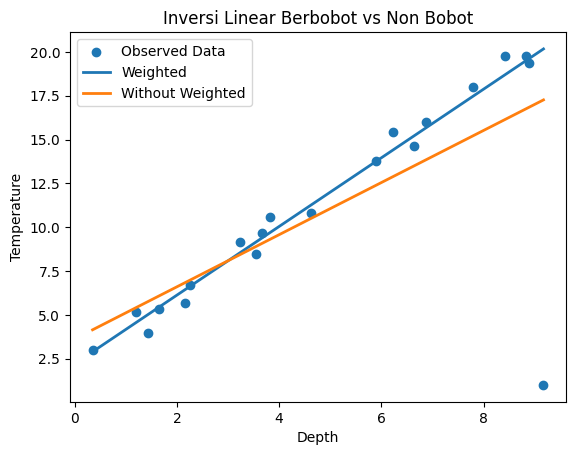

: 

In [ ]:
import numpy as np                              #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 #import library matplotlib untuk memvisualisasikan grafik
from numpy.linalg import inv                    #dari numpy untuk import fungsi invers matriks

# Generated data dummy (misal data kedalaman)
N = 20                                          #Mendefinisikan n titik data sebanyak 20

zmin = 0                                        #Mendefinisikan kedalaman minimum = 0
zmax = 10                                       #Mendefinisikan kedalaman max = 10

Z = np.sort(np.random.uniform(zmin, zmax, N))   #menambahkan titik kedalaman acak dari keil ke besar

# Generated data observasi temperatur
a = 2                                           #mendefinisikan a (intercept)
b = 2                                           #mendefinisikan b (gradien)

sd = 0.5                                        #Mendefinisikan standar deviasi

Tobs = a + b * Z + np.random.normal(0, sd, N)   #menghitung Tobs ditambah noise

# Membuat data outlier
Tobs[N-1] = 1                                   #mengganti data terakhir dengan nilai = 1 untuk mensimulasikan outlier 

# Membuat matriks bobot (subjective weight)
w = np.eye(N)                                   #membuat weighted matrix
w[N-1][N-1] = 0.1                               #mengubah bobot data outlier  menjadi 0.1 agar pengaruhnya terhadap solusi diminimalkan

# Membuat matriks kernel G
G = np.zeros((N, 2))                            #membuat matrix kernel nx2

for i in range(N):
    G[i][0] = 1                                 #matrix kolom pertama adalah 1
    G[i][1] = Z[i]                              #matrix kolom kedua koefisien parameter gradien b

# Mengubah data menjadi matriks kolom
d = np.reshape(Tobs, (N, 1))                    #mengubah matrix Tobs menjadi matrix kolom nx1

# Perhitungan inversi linear berbobot
m = inv(G.T @ w @ G) @ G.T @ w @ d              #menghitung m dengan weighted least square

a_est = m[0][0]                                 #mengekstrak nilai estimasi a dari hasil inversi berbobot
b_est = m[1][0]                                 #mengekstrak nilai estimasi b dari hasil inversi berbobot

# Model hasil inversi
Tcalc_weighted = a_est + b_est * Z              #menghitung T kalkulasi weighted dengan parameter hasil inversi

# Inversi tanpa bobot
m2 = inv(G.T @ G) @ G.T @ d                     #menghitung m dengan Least Squares

a2 = m2[0][0]                                   #mengekstrak nilai estimasi a dari hasil inversi tanpa bobot
b2 = m2[1][0]                                   #mengekstrak nilai estimasi b dari hasil inversi tanpa bobot

Tcalc_unweighted = a2 + b2 * Z                  #menghitung T kalkulasi unwighted 

# Menghitung misfit
misfit_weighted = np.sum((Tobs - Tcalc_weighted)**2)        #menghitung misfit weighted sebagai jumlah kuadrat selisih data observasi dan model berbobot
misfit_unweighted = np.sum((Tobs - Tcalc_unweighted)**2)    #menghitung misfit unweighted sebagai jumlah kuadrat selisih data observasi dan model 

print("Misfit with weighted :", misfit_weighted)            #menampilkan misfit hasil weighted inversion
print("Misfit without weighted :", misfit_unweighted)       #menampilkan misfit hasil unweighted inversion

# Plot hasil
plt.scatter(Z, Tobs, label='Observed Data') #memplot label data observasi
plt.plot(Z, Tcalc_weighted, label='Weighted', linewidth=2) #memplot label weighted
plt.plot(Z, Tcalc_unweighted, label='Without Weighted', linewidth=2) #memplot label without weighted

plt.xlabel("Depth") #menyatakan plot sumbu x adalah depth
plt.ylabel("Temperature") #menyatakan plot sumbu y adalah temperatur
plt.title("Inversi Linear Berbobot vs Non Bobot") #membuat judul 
plt.legend() #plot legenda
plt.show() #plot show


#pada hasil inversi linear berbobot dan tidak berbobot terlihat pada gambar 
#terdapat data observasi yang outlier pada kanan bawah. akan tetapi selain data 
#outlier data observasi lainnya mengikuti tren linear weighted.

hasil estimasi v1 setelah koreksi:  1473.3617 m/s
hasil estimasi v2 setelah koreksi:  1473.3617 m/s


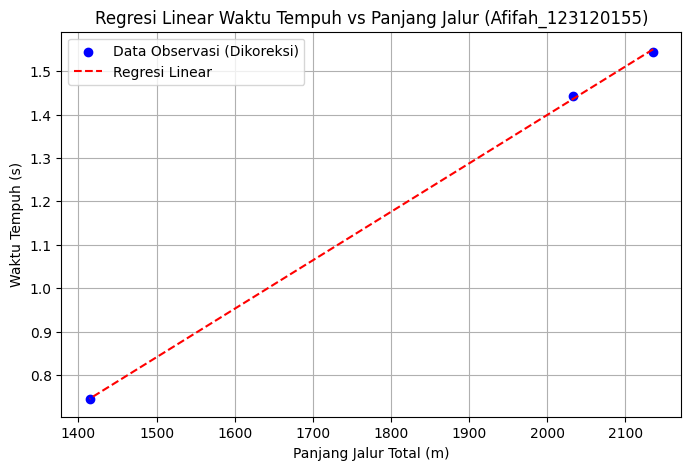

In [ ]:
import numpy as np                              #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 #import library matplotlib untuk memvisualisasikan grafik
from numpy.linalg import inv                    #dari numpy untuk import fungsi invers matriks

#koordinat hiposenter (s1, s2,s3) dalam meter
hiposenter = np.array([         #mendefinisikan koordinat hiposenter
    [0, -250],                  #s 1
    [0, -633],                  #s 2
    [1000, 0]                   #s 3
])

#koordinat stasiun seismik (r1, r2) dalam meter
stasiun = np.array([            #mendefinisikan koordinat stasiun seismik
    [2000, -1000],              #r1
    [0, -1000]                  #r2
])

# Menghitung panjang jalur (ray path) menggunakan rumus Pythagoras
l_11 = np.sqrt((hiposenter[0, 0] - stasiun[0, 0])**2 + (hiposenter[0, 1] - stasiun[0, 1])**2)
l_21 = np.sqrt((hiposenter[1, 0] - stasiun[0, 0])**2 + (hiposenter[1, 1] - stasiun[0, 1])**2)
l_31 = np.sqrt((hiposenter[2, 0] - stasiun[0, 0])**2 + (hiposenter[2, 1] - stasiun[0, 1])**2)
#menghitung panjang ray path dari sumber gempa 

# Rasio R1b terhadap R1R2 (Setengah panjang R1R2)
r1b_ratio = 0.5 #nilai ini untuk membagi lintasan gelombang

#menghitung panjang jalur rib untuk tiap sumber gempa
delta_l1 = r1b_ratio * l_11         #menghitung panjang jalur rib untuk sumber gempa ke-1
delta_l2 = r1b_ratio * l_21         #menghitung panjang jalur rib untuk sumber gempa ke-2
delta_l3 = r1b_ratio * l_31         #menghitung panjang jalur rib untuk sumber gempa ke-3

#matriks desain G (panjang jalur untuk tiap blok)
G = np.array([                      #menyatakan matrix G (jalur ray) masing masing model
    [delta_l1, l_11 - delta_l1],    
    [delta_l2, l_21 - delta_l2],
    [delta_l3, l_31 - delta_l3]
])

#waktu tempuh observasi setelah dikoreksi
d_obs = np.array([1.544, 1.444, 0.744]) #s3 sudah dikoreksi

#matriks bobot (misal, bobot berdasarkan ketelitian data)
W = np.diag([1, 0.8, 1]) #tidak ada bobot khusus disini, jika ada kesalahan pada s3 maka nilai <1, dis

#menghitung inversi linear berbobot
GTWG = G.T @ W @ G
GTWd = G.T @ W @ d_obs
m = np.linalg.pinv(GTWG) @ GTWd #menggunakan pseudoinverse untuk menghindari singular matriks

#hasil estimasi kecepatan v1 dan v2
v1 = 1 / m[0] #kecepatan lapisan pertama
v2 = 1 / m[1] #kecepatan lapisan kedua

print(f"hasil estimasi v1 setelah koreksi: {v1: .4f} m/s")
print(f"hasil estimasi v2 setelah koreksi: {v1: .4f} m/s")

#plot regresi linear antara panjang jalur dan waktu tempuh
plt.figure(figsize=(8, 5))
plt.scatter(G[:, 0] + G[:, 1], d_obs, color='blue', label='Data Observasi (Dikoreksi)')
m_reg, b_reg = np.polyfit(G[:, 0] + G[:, 1], d_obs, 1)  # Regresi linear
plt.plot(G[:, 0] + G[:, 1], m_reg * (G[:, 0] + G[:, 1]) + b_reg, color='red', linestyle='--', label='Regresi Linear')

plt.xlabel('Panjang Jalur Total (m)')   #plot sumbu x menyatakan panjang jalur total
plt.ylabel('Waktu Tempuh (s)')          #plot sumbu y sebagai waktu tempuh
plt.title('Regresi Linear Waktu Tempuh vs Panjang Jalur (Afifah_123120155)') #plot judul
plt.legend()                            #plot legenda
plt.grid()                              #plot bentuk grid
plt.show()                              #plot 


#hasil estimasi sama karena v1=v2, dan data observasi terlihat fit dengan model

<div style="
font-family:'Times New Roman';
width:75%;
margin-left:auto;
margin-right:auto;
line-height:1.7;
text-align:justify;
">

<h1 style="text-align:center; font-size:20pt"><b>LAMPIRAN</b></h1> 

<p align="center">
  <img src="https://github.com/vvvailable/inversi/blob/main/WhatsApp%20Image%202026-02-27%20at%2015.04.35.jpeg?raw=true" width="600">
</p>
<div style="font-family: 'Times New Roman', Times, serif; margin: 20px auto; width: 80%;">
    <p style="text-align: center;">
  Lampiran 1. Bukti mengikuti Praktikum
    </p></div>